# Vision-Language Models (VLMs) from Scratch: Basic Principles Explained

    Welcome! If you know some basic Python but have never touched a Vision-Language Model (VLM) before, you are in exactly the right place.

## 1. Introduction: What is a VLM?

Historically, AI models were hyper-specialized. You had "computer vision" models that could detect cars in a photo, and "natural language" models that could translate French to English. But they couldn't talk to each other. 

A **Vision-Language Model (VLM)** is like a perfectly bilingual translator who fluently speaks both "Image" and "Text". By understanding both modalities at the same time, VLMs can perform incredible feats:
* **Visual Question Answering (VQA):** "What color is the umbrella in this photo?"
* **Image Captioning:** Automatically writing "A golden retriever catching a frisbee."
* **Zero-Shot Classification:** Categorizing images into classes the model was never explicitly trained on, just by reading the class names!

**Why this is revolutionary:** We no longer need to train a new, custom AI for every specific visual task. We can just use text to "ask" the vision model what to do!

**Prerequisites for this notebook:**
* Basic Python & NumPy.
* That's it! We will explain the math and the machine learning concepts as we go.

## 2. Core Concepts – The Big Picture

How do we get an image of a dog and the word "dog" to mean the same thing to a computer? 

We use a concept called **Two Towers** and a **Shared Embedding Space**.

Imagine a massive, multidimensional room (the "Shared Embedding Space"). 
1. We send an image through a **Vision Encoder** (Tower 1). Its job is to look at the pixels and assign the image a specific set of coordinates in the room.
2. We send text through a **Text Encoder** (Tower 2). Its job is to look at the words and assign the text a specific set of coordinates in the *exact same room*.

If the model is well-trained, the coordinates for the image of a dog and the text "a photo of a dog" will be right next to each other!

```mermaid
graph LR
    I[🖼️ Image] --> VE(Vision Encoder)
    T[📝 Text] --> TE(Text Encoder)
    VE -->|Outputs Image Vector| Space((Shared Vector Space))
    TE -->|Outputs Text Vector| Space
    Space -.->|Matching concepts are pulled together| Space

    The "secret sauce" that makes this work is Contrastive Learning. It acts like a strict matchmaker: 
    it pulls matching image-text pairs closer together in the room, and pushes mismatched pairs far apart.

## 3. Math Made Easy: Embeddings and Similarity

When an encoder outputs "coordinates," we call that an **Embedding** or a **Vector**. It's just a list of numbers. 

To figure out if an image vector and a text vector are pointing to the same concept, we measure the angle between them. This is called **Cosine Similarity**.

### The Math
If we have an image vector $I$ and a text vector $T$, the cosine similarity $S_c(I,T)$ is calculated as:

$$S_c(I,T) = \frac{I \cdot T}{\|I\| \|T\|}$$

* $I \cdot T$ (The dot product): Multiply the matching numbers in the lists together and add them up. If they point in the same direction, this number gets big.
* $\|I\| \|T\|$ (The magnitudes): This just scales the result so the final score is always between **-1** (exact opposites) and **1** (perfect match). A score of **0** means they are completely unrelated.

Let's visualize this with some code!

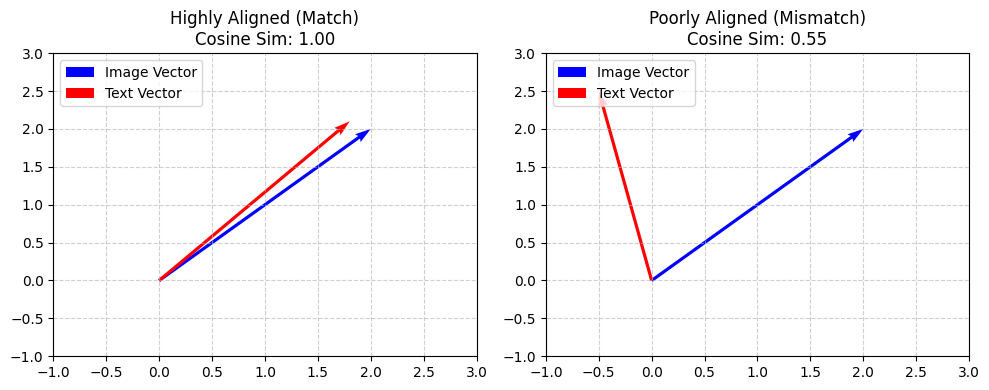

In [1]:
# Run this cell to visualize Cosine Similarity!
import numpy as np
import matplotlib.pyplot as plt

def plot_vectors(v1, v2, title, ax):
    ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='blue', label='Image Vector')
    ax.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='red', label='Text Vector')
    ax.set_xlim(-1, 3)
    ax.set_ylim(-1, 3)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Calculate cosine similarity
    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    cos_sim = dot_product / (norm_v1 * norm_v2)
    
    ax.set_title(f"{title}\nCosine Sim: {cos_sim:.2f}")
    ax.legend(loc='upper left')

# Create our plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Scenario 1: Highly aligned (A dog image and "a photo of a dog")
img_vec_1 = np.array([2, 2])
text_vec_1 = np.array([1.8, 2.1])
plot_vectors(img_vec_1, text_vec_1, "Highly Aligned (Match)", ax1)

# Scenario 2: Poorly aligned (A dog image and "a photo of a car")
img_vec_2 = np.array([2, 2])
text_vec_2 = np.array([-0.5, 2.5])
plot_vectors(img_vec_2, text_vec_2, "Poorly Aligned (Mismatch)", ax2)

plt.tight_layout()
plt.show()

# What you should see:
# Two graphs. The left graph shows arrows pointing almost the same way (Similarity ~ 1.0).
# The right graph shows arrows pointing apart (Similarity is much lower).

### Try it yourself!
Change the numbers in the cell below to see how cosine similarity changes. Try to make a cosine similarity of exactly `0.0` (Hint: make the vectors perpendicular, like `[0, 2]` and `[2, 0]`).

In [5]:
# Try it yourself: change these lists of two numbers!
my_image_vector = np.array([1.0, 1.0])
my_text_vector = np.array([1.0, 1.0])

cos_sim = np.dot(my_image_vector, my_text_vector) / (np.linalg.norm(my_image_vector) * np.linalg.norm(my_text_vector))
print(f"Your Cosine Similarity is: {cos_sim:.4f}")

Your Cosine Similarity is: 1.0000
